In [2]:
%pip install pandas scikit-learn matplotlib seaborn numpy;

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

# Carregar o dataset
dados = pd.read_csv('diabetes.csv')
# Exibir as primeiras linhas do dataset
dados.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
dados.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
dados.shape

(768, 9)

In [6]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
dados.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Não há colunas com dados nulos

In [8]:
#(data == 0).sum()

contagem_zero = (dados == 0).sum().reset_index()
contagem_zero.columns = ['Coluna', 'Contagem de Zeros']
print(contagem_zero)

                     Coluna  Contagem de Zeros
0               Pregnancies                111
1                   Glucose                  5
2             BloodPressure                 35
3             SkinThickness                227
4                   Insulin                374
5                       BMI                 11
6  DiabetesPedigreeFunction                  0
7                       Age                  0
8                   Outcome                500


Não temos valores nulos, mas temos valores zero em algumas colunas. Acima está indicado quantos valores zero existe em cada coluna.
A coluna Insulin e SkinThickness possuem um valor muito alto de valores zerados.

Do total de 768 entradas, 500 são resultados negativos (outcome).

In [9]:
#verificar duplicidades
dados.duplicated().sum()

np.int64(0)

Não há duplicidades

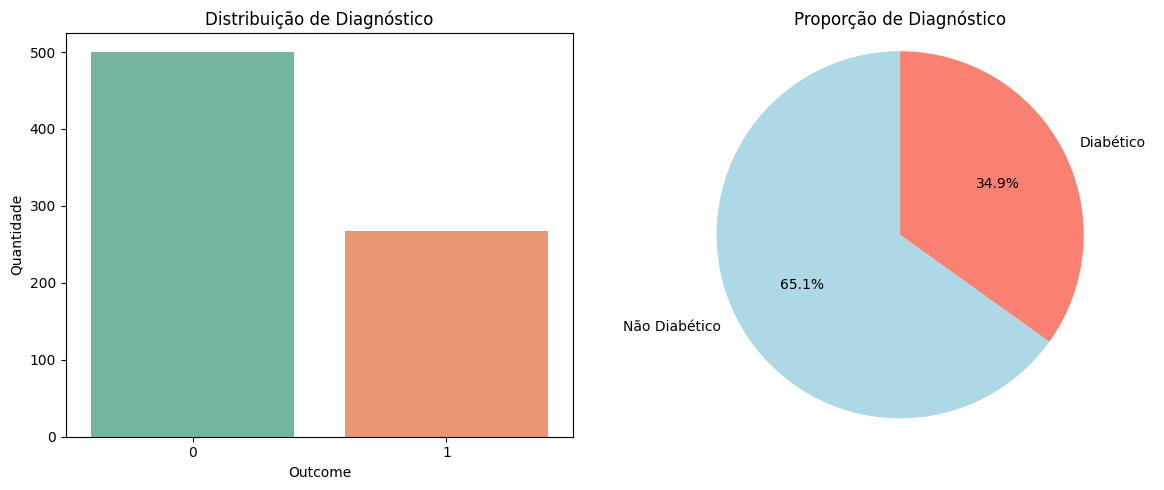

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

contagem = dados['Outcome'].value_counts()
labels = ['Não Diabético', 'Diabético']

fig, axes = plt.subplots(1,2, figsize=(12,5))

#Grafico de barras
sns.countplot(x='Outcome', data=dados, ax=axes[0], hue='Outcome', legend=False, palette='Set2')
axes[0].set_title('Distribuição de Diagnóstico')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Quantidade')

#Grafico de pizza
axes[1].pie(contagem, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
axes[1].set_title('Proporção de Diagnóstico')
axes[1].axis('equal')

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Distribuição da Insulina (2-Hour serum insulin (mu U/ml))')

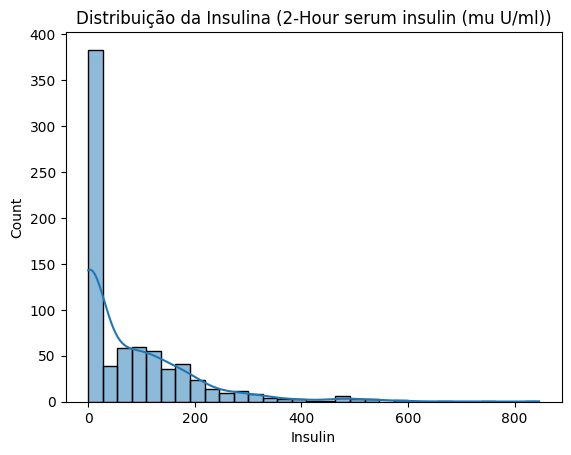

In [11]:
sns.histplot(dados['Insulin'], kde=True)
plt.title('Distribuição da Insulina (2-Hour serum insulin (mu U/ml))')

In [12]:
proporcao_zero_insulin = len(dados[dados['Insulin'] == 0]) / len(dados)
print(f'Proporção de valores zero na coluna Insulin: {proporcao_zero_insulin:.2%}')

Proporção de valores zero na coluna Insulin: 48.70%


- Tem muitos dados faltantes na coluna de insulina. 
- Vamos testar preenchendo com a mediana (pode causar um viés pois 374 valores estarão idênticos) 
- Ou dropando essa coluna inteiramente. 

Tranformo os valores zerados de Insulina para Nulos(NaN)

In [13]:
import numpy as np
# Substituir os valores zero por NaN
dados['Insulin'] = dados['Insulin'].replace(0, np.nan)
dados[dados['Insulin'].isna()].head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,NaN,33.6,0.627,50,1
1,1,85,66,29,NaN,26.6,0.351,31,0
2,8,183,64,0,NaN,23.3,0.672,32,1
5,5,116,74,0,NaN,25.6,0.201,30,0
7,10,115,0,0,NaN,35.3,0.134,29,0


In [14]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

dados['Insulin'] = imputer.fit_transform(dados[['Insulin']])
dados.head()

# Verificar a proporção de valores NaN após a imputação
#proporcao_nan_insulin_após_imputacao = dados['Insulin_imputada'].isna().mean()
#print(f'Proporção de valores NaN na coluna Insulin após imputação: {    proporcao_nan_insulin_após_imputacao:.2%}') 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125.0,33.6,0.627,50,1
1,1,85,66,29,125.0,26.6,0.351,31,0
2,8,183,64,0,125.0,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


Text(0.5, 1.0, 'Distribuição da Insulina (2-Hour serum insulin (mu U/ml))')

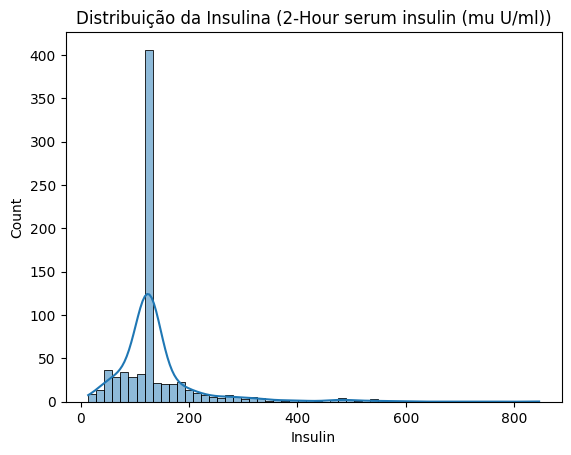

In [15]:
sns.histplot(dados['Insulin'], kde=True)
plt.title('Distribuição da Insulina (2-Hour serum insulin (mu U/ml))')

### Glicose (Glucose)
Tratamento dos dados de glicose
- Converto dados zerados para Nulos
- Aplicamos o transform do SimpleImputer também utilizando a estratégia de mediana. 

In [16]:
dados['Glucose'] = dados['Glucose'].replace(0, np.nan)
dados['Glucose'] = imputer.fit_transform(dados[['Glucose']]) 

Text(0.5, 1.0, 'Distribuição da Glicose')

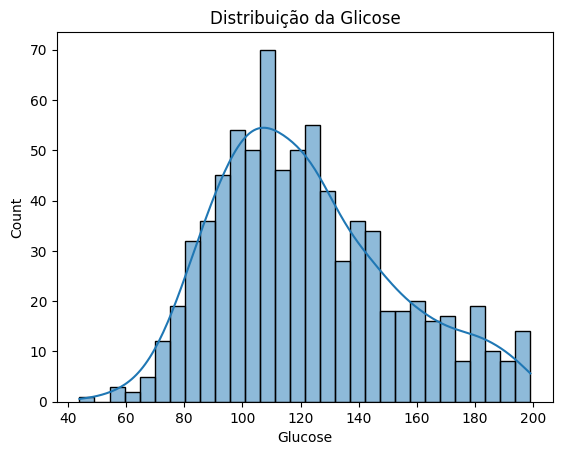

In [17]:
sns.histplot(dados['Glucose'], bins=30, kde=True)
plt.title('Distribuição da Glicose')

<Axes: xlabel='Outcome', ylabel='Glucose'>

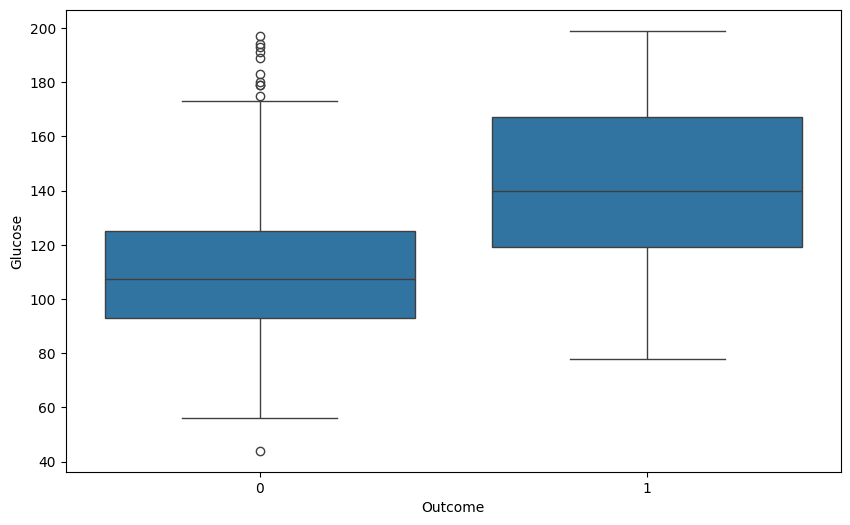

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='Glucose', data=dados)

Text(0.5, 1.0, 'Boxplot de Insulina por Outcome')

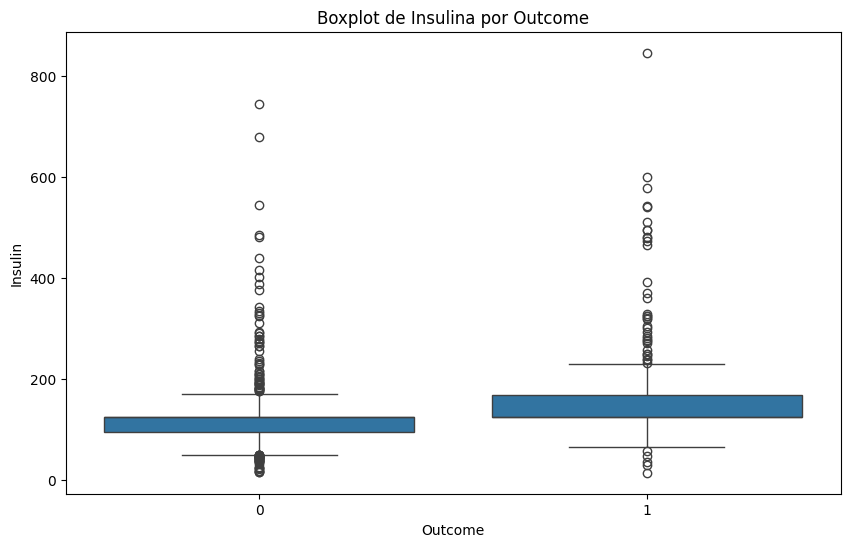

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='Insulin', data=dados) 
plt.title('Boxplot de Insulina por Outcome')

Text(0.5, 1.0, 'Relação entre Glicose e Insulina por Outcome')

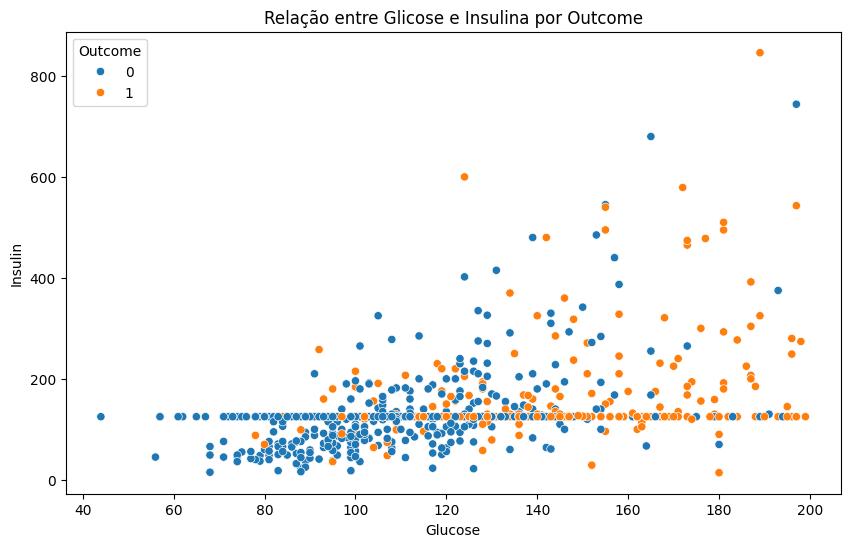

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='Insulin', hue='Outcome', data=dados)
plt.title('Relação entre Glicose e Insulina por Outcome')

Após o tratamento de valores zerados, existe um valor concentrado de insulina, o que pode causar um viés no modelo. 

### Pressão arterial (BloodPressure)

Text(0.5, 1.0, 'Distribuição da Pressão Arterial (mm Hg)')

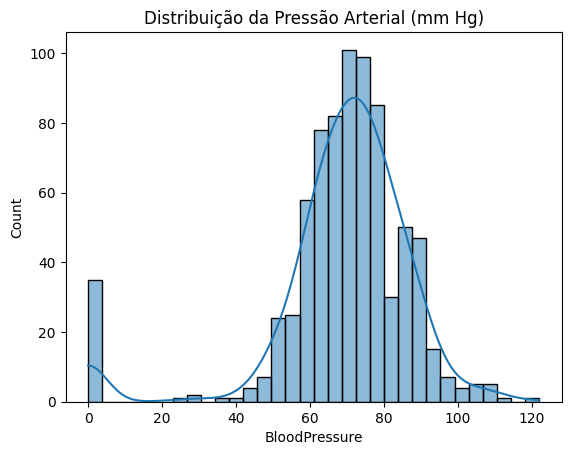

In [21]:
sns.histplot(dados['BloodPressure'], kde=True)
plt.title('Distribuição da Pressão Arterial (mm Hg)')

Vamos tratar os valores zerados de pressão arterial

Text(0.5, 1.0, 'Distribuição da Pressão Arterial (mm Hg)')

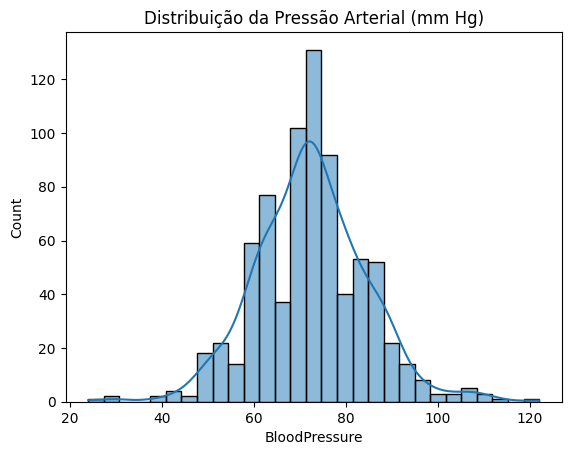

In [22]:
dados['BloodPressure'] = dados['BloodPressure'].replace(0, np.nan)
dados['BloodPressure'] = imputer.fit_transform(dados[['BloodPressure']])

sns.histplot(dados['BloodPressure'], kde=True)
plt.title('Distribuição da Pressão Arterial (mm Hg)')

<Axes: xlabel='Outcome', ylabel='BloodPressure'>

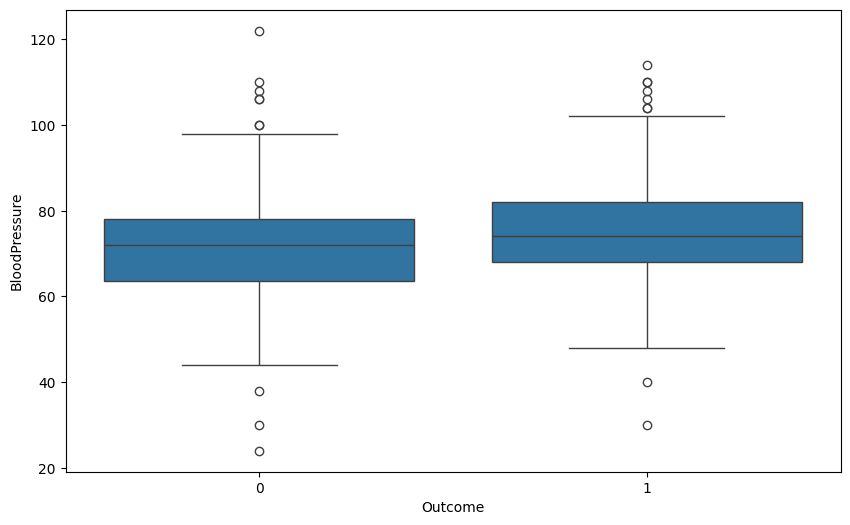

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='BloodPressure', data=dados) 

- A pressão sanguinea para o diagnóstico positivo pode ser levemente mais alta.

### IMC (BMI)

Text(0.5, 1.0, 'Distribuição do IMC (kg/m²)')

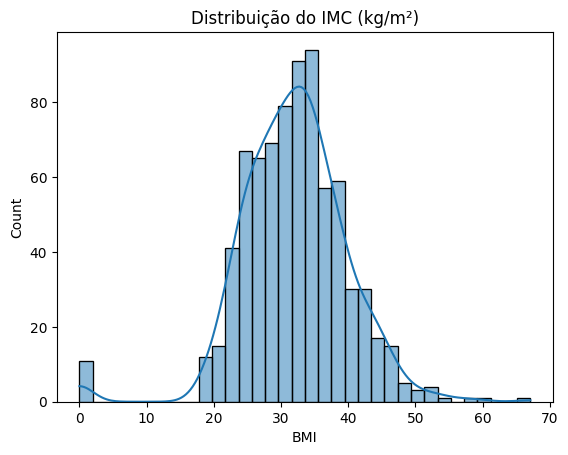

In [24]:
sns.histplot(dados['BMI'], kde=True)
plt.title('Distribuição do IMC (kg/m²)')

Text(0.5, 1.0, 'Distribuição do IMC (kg/m²)')

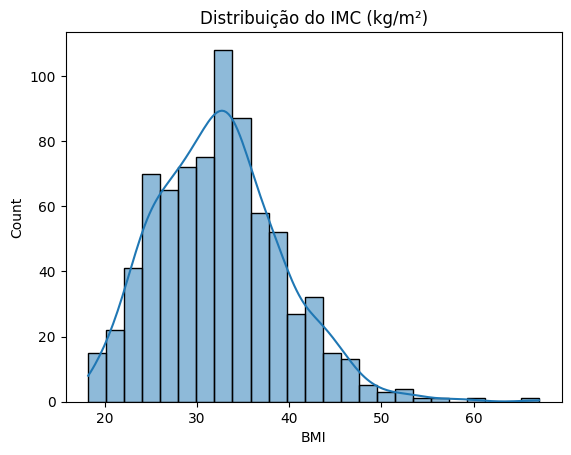

In [25]:
dados['BMI'] = dados['BMI'].replace(0, np.nan)
dados['BMI'] = imputer.fit_transform(dados[['BMI']])
sns.histplot(dados['BMI'], kde=True)
plt.title('Distribuição do IMC (kg/m²)')

Text(0.5, 1.0, 'Boxplot de IMC por Outcome')

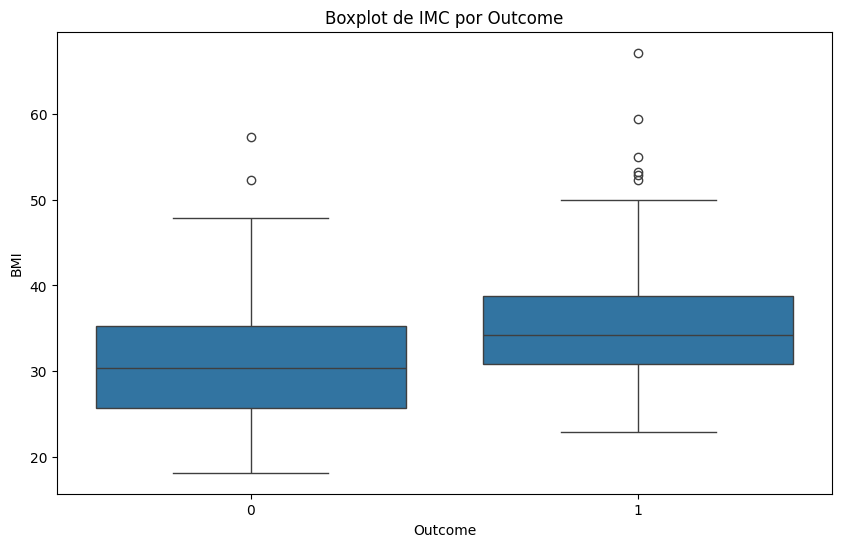

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='BMI', data=dados)
plt.title('Boxplot de IMC por Outcome')
    

O IMC de indivíduos com diagnóstico positivo tende a ser um pouco maior.

Text(0.5, 1.0, 'Boxplot de Idade por Outcome')

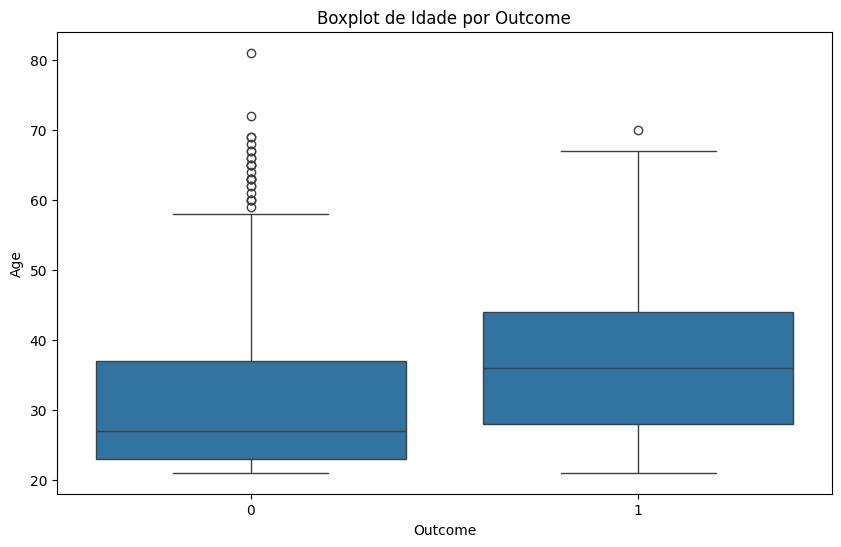

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='Age', data=dados) 
plt.title('Boxplot de Idade por Outcome')

A concentração de diagnóstico positivo tem maior concentração a partir de indivíduos após os 30 anos de idade

Text(0.5, 1.0, 'Relação entre Glicose e Idade por Outcome')

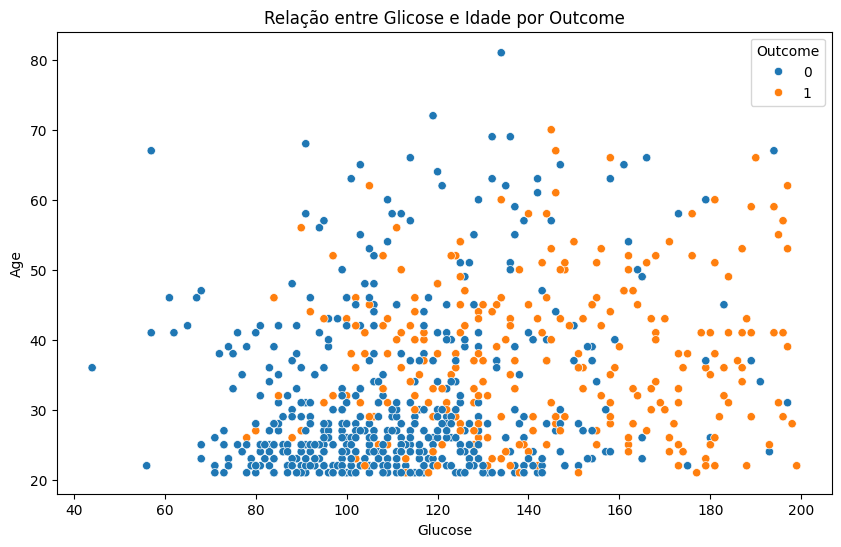

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='Age', hue='Outcome', data=dados)
plt.title('Relação entre Glicose e Idade por Outcome')

Nos mais jovens se concentra o diagnóstico negativo, mesmo em indivíduos com glicose média para alta, porém quanto mais alta a glicose, mesmo indivíduos jovens foram diagnosticados positivamente.
Temos alguns outliers com glicose alta e diagnóstico negativo.

Text(0.5, 1.0, 'Relação entre Glicose e IMC por Outcome')

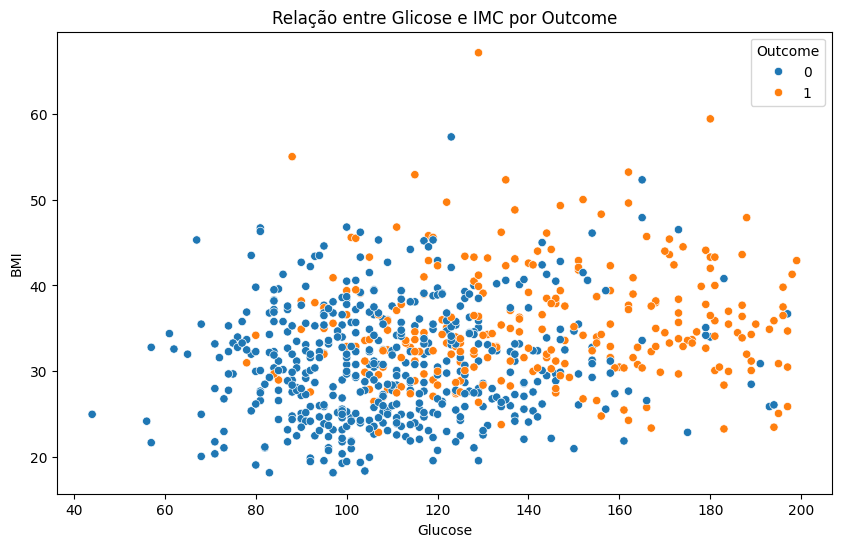

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=dados)
plt.title('Relação entre Glicose e IMC por Outcome')

### Propensão hereditária (DiabetesPedigreeeFunction)

Text(0.5, 1.0, 'Distribuição do Diabetes Pedigree Function')

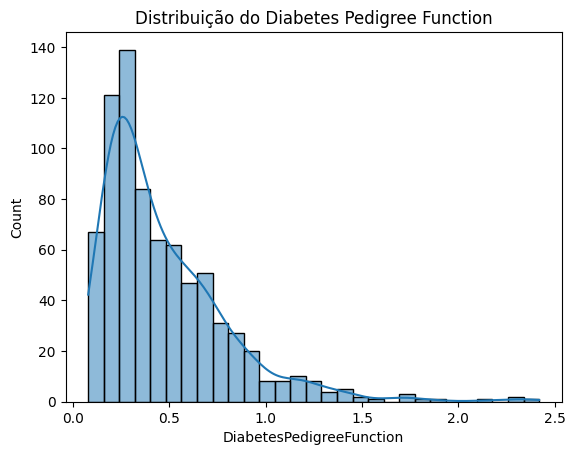

In [64]:
sns.histplot(dados['DiabetesPedigreeFunction'], kde=True)
plt.title('Distribuição do Diabetes Pedigree Function')

Text(0.5, 1.0, 'Relação entre Glicose e Diabetes Pedigree Function por Outcome')

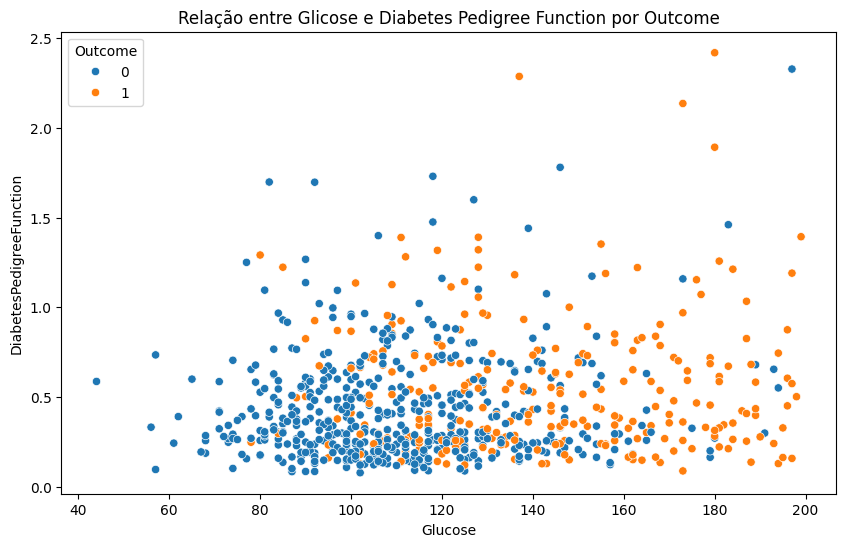

In [30]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='DiabetesPedigreeFunction', hue='Outcome', data=dados)
plt.title('Relação entre Glicose e Diabetes Pedigree Function por Outcome')

Text(0, 0.5, 'Idade')

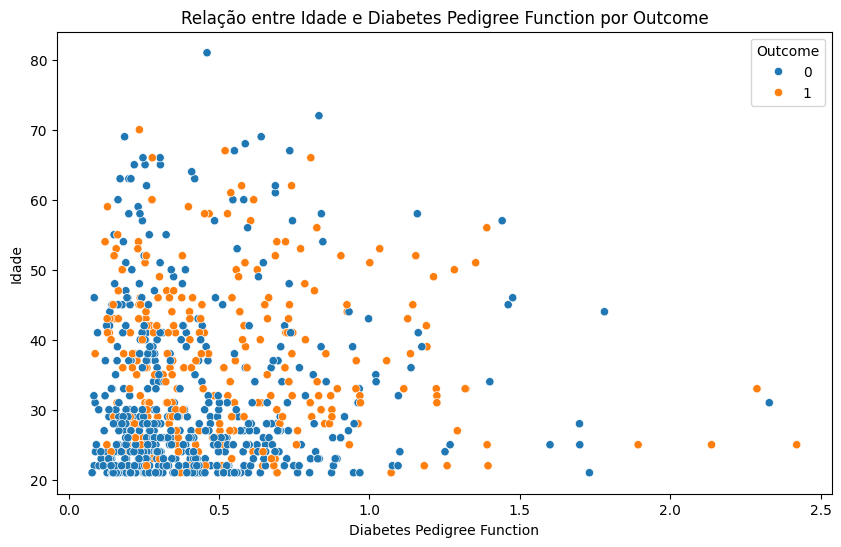

In [63]:
plt.figure(figsize=(10, 6))
sns.scatterplot(y='Age', x='DiabetesPedigreeFunction', hue='Outcome', data=dados)
plt.title('Relação entre Idade e Diabetes Pedigree Function por Outcome')
plt.xlabel('Diabetes Pedigree Function')
plt.ylabel('Idade')    

Text(0.5, 1.0, 'Boxplot de Diabetes Pedigree Function por Outcome')

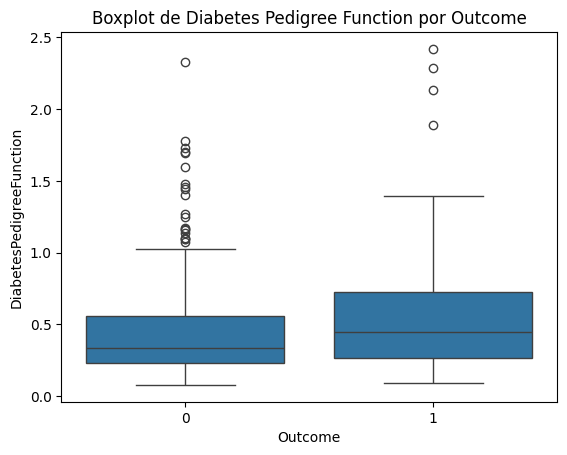

In [32]:
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=dados)
plt.title('Boxplot de Diabetes Pedigree Function por Outcome')

No boxplot dá pra perceber que há uma concentração maior para as pessoas com propenção hereditária para diagnóstico de diabetes no diagnóstico positivo.

### Espessura da pele (SkinThickness)

Text(0.5, 1.0, 'Boxplot de Espessura da Pele por Outcome')

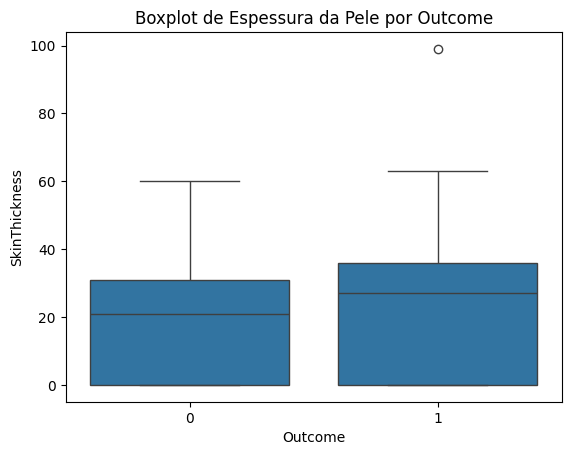

In [33]:
sns.boxplot(x='Outcome', y='SkinThickness', data=dados)
plt.title('Boxplot de Espessura da Pele por Outcome')

A concentração de espessura da pele fica concentrada na parte onde ajustamos os valores zerados, mostrando um viés negativo.

Text(0.5, 1.0, 'Distribuição da Espessura da Pele (mm)')

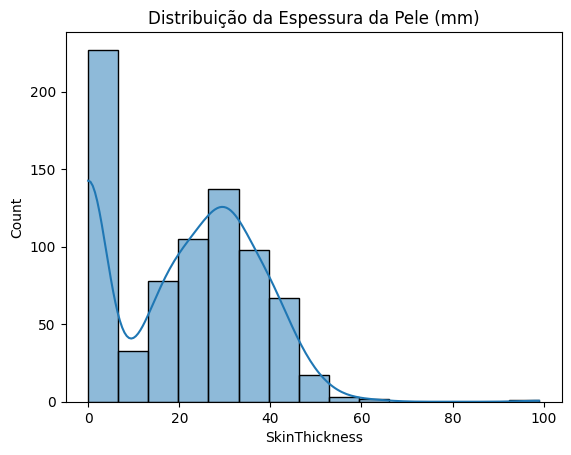

In [34]:
sns.histplot(dados['SkinThickness'], kde=True)
plt.title('Distribuição da Espessura da Pele (mm)')

Text(0.5, 1.0, 'Distribuição da Espessura da Pele (mm)')

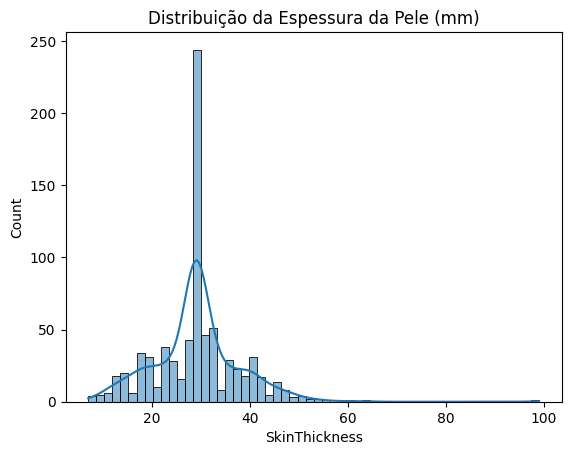

In [35]:
dados['SkinThickness'] = dados['SkinThickness'].replace(0, np.nan)
dados['SkinThickness'] = imputer.fit_transform(dados[['SkinThickness']])    

sns.histplot(dados['SkinThickness'], kde=True)
plt.title('Distribuição da Espessura da Pele (mm)')

Text(0.5, 1.0, 'Relação entre Glicose e Espessura da Pele por Outcome')

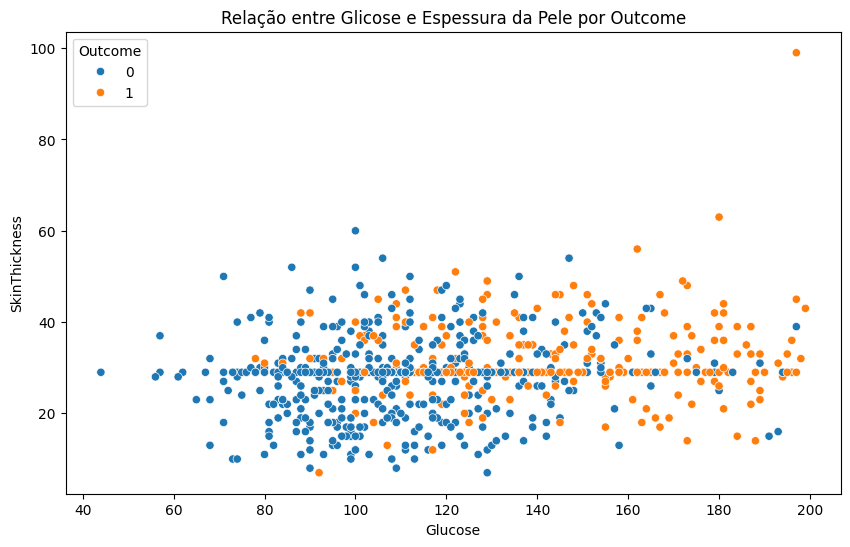

In [36]:
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x='Glucose', y='SkinThickness', hue='Outcome', data=dados)
ax.set_title('Relação entre Glicose e Espessura da Pele por Outcome')

Com tantos dados agrupados, o modelo pode ficar enviesado na mediana.

Text(0.5, 1.0, 'Relação entre IMC e Espessura da Pele por Outcome')

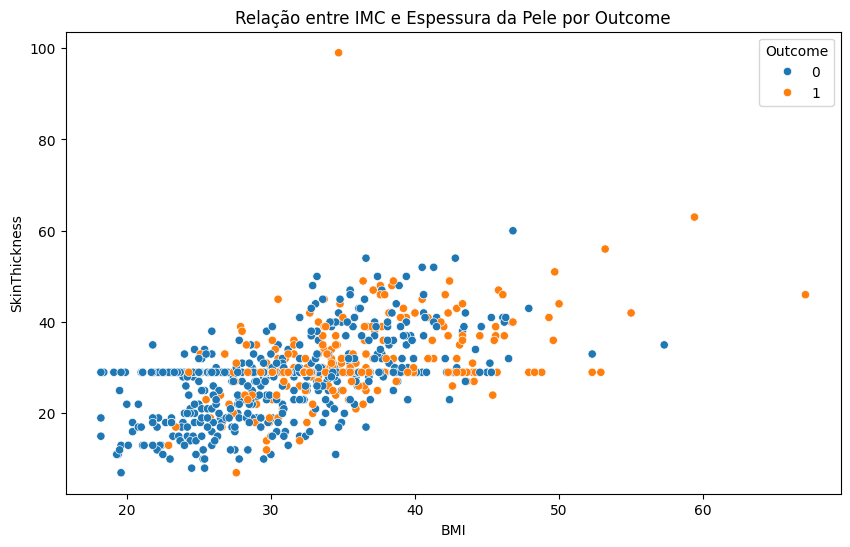

In [37]:
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x='BMI', y='SkinThickness', hue='Outcome', data=dados)
ax.set_title('Relação entre IMC e Espessura da Pele por Outcome')

A espessura da pele cresce junto com o valor de IMC. 
O valor de IMC pode ser mais adequado para o modelo pois está com informações mais completas, e pode trazer menos viés ao modelo. 

### Gráfico de gestações (Pregnancies)

Text(0.5, 1.0, 'Distribuição do Número de Gestações')

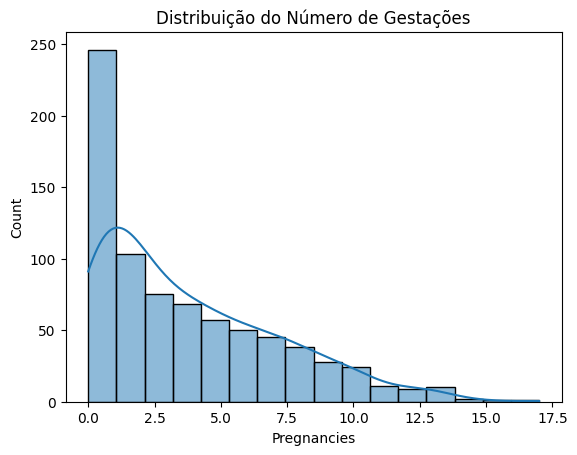

In [38]:
sns.histplot(dados['Pregnancies'], kde=True)
plt.title('Distribuição do Número de Gestações')

Os valores zerados de gravidez é uma medida válida pois indicam mulheres sem filhos.

### A seguir avaliamos o gráfico de correlação. 

Text(0.5, 1.0, 'Matriz de Correlação')

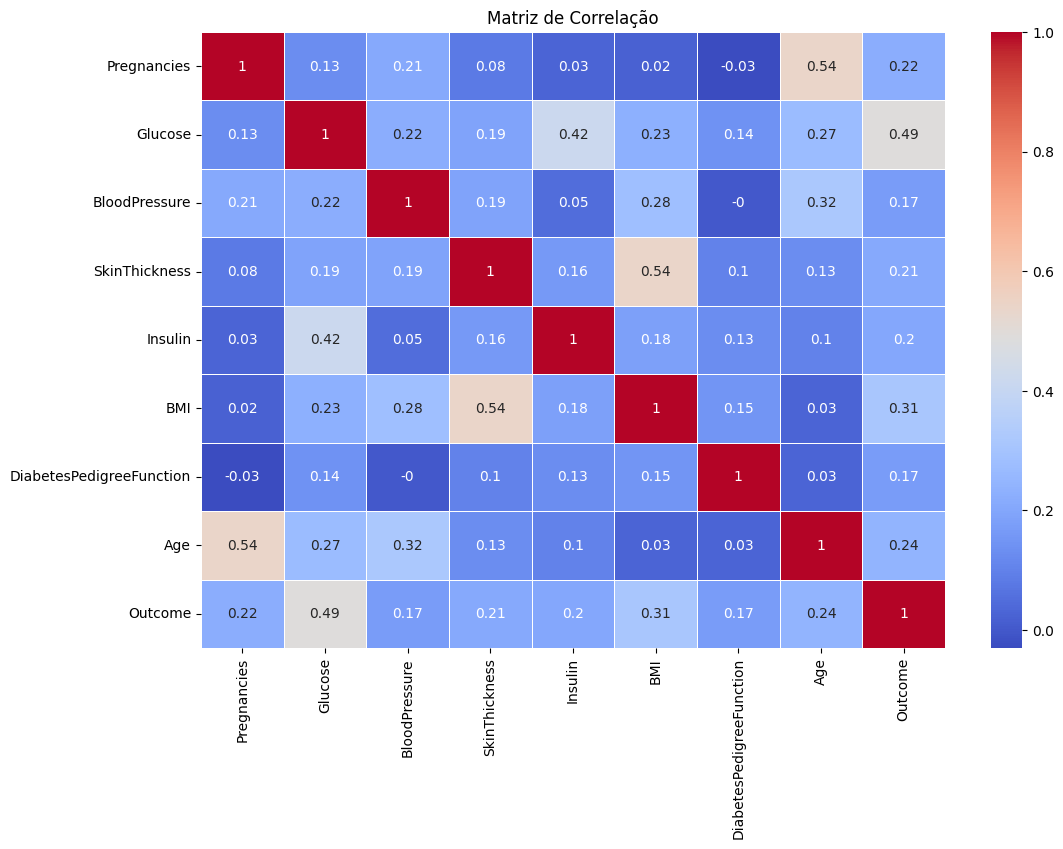

In [39]:
#matriz de correlação
correlacao = dados.corr().round(2)

plt.figure(figsize=(12, 8)) 
sns.heatmap(correlacao, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação')


No gráfico de correlação podemos notar que:
- A variável de glicose é a que mais influencia o outcome positivo.
- Glicose e Insulina tem alguma correlação. 
- A correlação entre idade e gravidez só nos diz que ao avançar da idade aumenta o número de gestações/filhos
- Indivíduos com maior IMC tem maior espessura da pele (SkinThickness)

## Vamos treinar o modelo

Decidi não utilizar os dados de Insulina e espessura da pele (SkinThickness) para não introduzir um viés para o modelo devido ao tratamento de transformação de valores zerados para mediana.

Drop dos dados:
- SkinThickness
- Insulin

Separar o modelo em treino e teste

In [40]:
from sklearn.model_selection import train_test_split

X = dados.drop(columns=['Outcome', 'SkinThickness', 'Insulin']) 
y = dados['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)





In [41]:
print("Proporções de Diagnóstico no Conjunto de Treino e Teste:")
print("Diagnóstico positivo - Treino:",list(y_train).count(1), " - Proporção:", list(y_train).count(1)/len(y_train))
print("Diagnóstico negativo - Treino:",list(y_train).count(0), " - Proporção:", list(y_train).count(0)/len(y_train))
print("Diagnóstico positivo - Teste:",list(y_test).count(1), " - Proporção:", list(y_test).count(1)/len(y_test))
print("Diagnóstico negativo - Teste:",list(y_test).count(0), " - Proporção:", list(y_test).count(0)/len(y_test))

Proporções de Diagnóstico no Conjunto de Treino e Teste:
Diagnóstico positivo - Treino: 214  - Proporção: 0.3485342019543974
Diagnóstico negativo - Treino: 400  - Proporção: 0.6514657980456026
Diagnóstico positivo - Teste: 54  - Proporção: 0.35064935064935066
Diagnóstico negativo - Teste: 100  - Proporção: 0.6493506493506493


### Feature Scaling
 - Vamos ajustar os dados para a mesma escala

In [42]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vou utilizar o StandardScaler para padronizar os dados, mas também vou criar uma versão com MinMaxScaler para comparação.
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)



In [43]:
dados_escalonados = pd.DataFrame(X_train_scaled, columns=X_train.columns)
dados_escalonados.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.056427,-0.826740,-0.769477,0.310794,-0.792169
1,0.356576,0.144399,0.477772,-0.417498,-0.116439,0.561034
2,-0.549372,-0.556083,-1.152868,0.359790,-0.764862,-0.707594
3,-0.851355,0.811525,-1.315932,-0.402832,0.262314,-0.369293
4,-1.153338,-0.889646,-0.663676,1.782373,-0.337630,-0.961320


Vamos treinar o modelo utilizando o KNN e depois o SVM

# KNN - K Nearest Neighbors

In [44]:
from sklearn.neighbors import KNeighborsClassifier

# Vamos primeiro descobrir o melhor valor de k
error = []

for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    error.append(np.mean(y_pred != y_test))

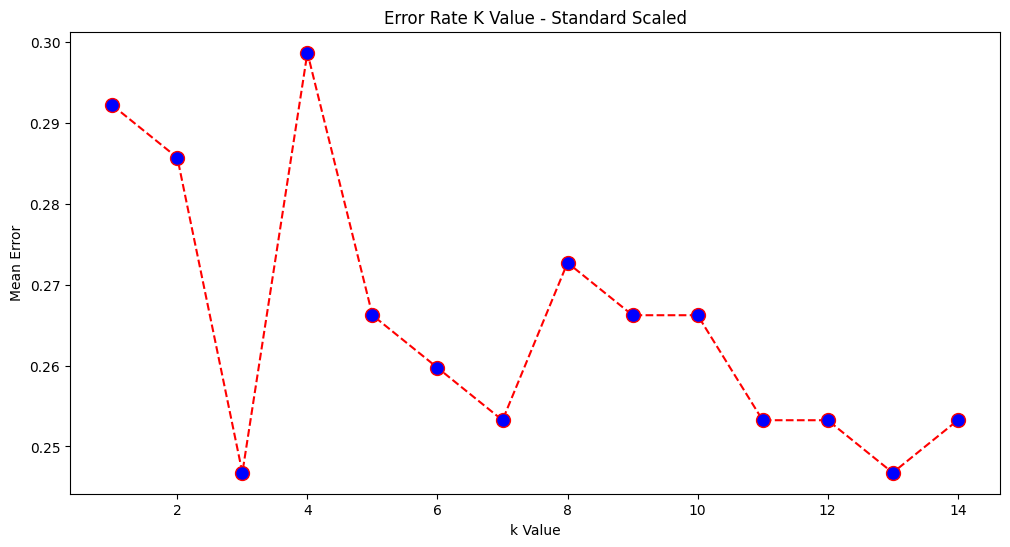

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 15), error, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.xlabel('k Value')
plt.ylabel('Mean Error')
plt.title('Error Rate K Value - Standard Scaled')
plt.show()

In [46]:
dados_scalonados_minmax = pd.DataFrame(X_train_minmax, columns=X_train.columns)
dados_scalonados_minmax.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,0.058824,0.237762,0.387755,0.184049,0.220935,0.050000
1,0.294118,0.489510,0.551020,0.233129,0.158129,0.316667
2,0.117647,0.342657,0.346939,0.341513,0.062806,0.066667
3,0.058824,0.629371,0.326531,0.235174,0.213808,0.133333
4,0.000000,0.272727,0.408163,0.539877,0.125612,0.016667


In [47]:
error_minmax = []

for i in range(1, 15):
    knn_minmax = KNeighborsClassifier(n_neighbors=i)
    knn_minmax.fit(X_train_minmax, y_train)
    y_pred_minmax = knn_minmax.predict(X_test_minmax)
    error_minmax.append(np.mean(y_pred_minmax != y_test))

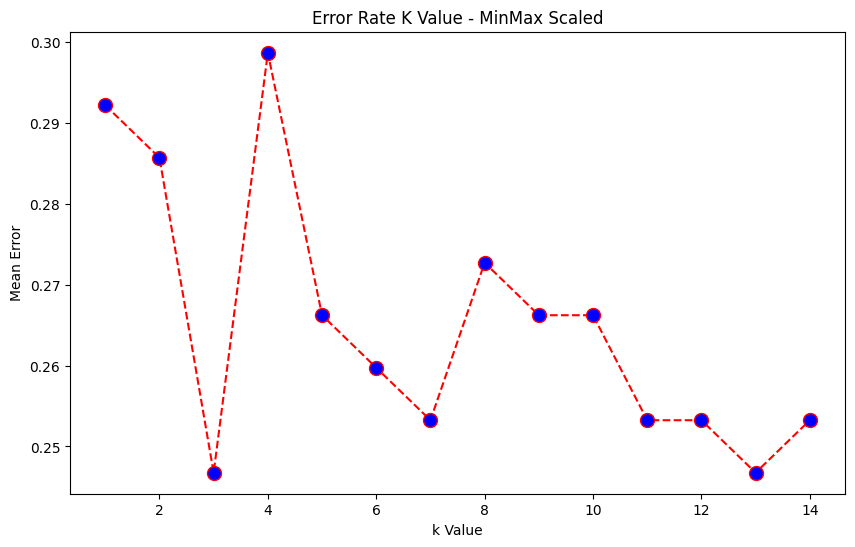

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 15), error, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.xlabel('k Value')
plt.ylabel('Mean Error')
plt.title('Error Rate K Value - MinMax Scaled')
plt.show()

O resultado foi o mesmo utilizando o StardardScaler ou o MinMaxScaler, porém vou utilizar o StardardScaler que é mais indicado para o modelo KNN

O melhor k encontrado foi 3 e 13, porém vou utilizar o 3 para evitar sobreajuste do modelo. 



In [49]:
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

In [50]:
from sklearn.metrics import accuracy_score
print("Acurácia do modelo KNN:", accuracy_score(y_test, y_pred_knn))

Acurácia do modelo KNN: 0.7532467532467533


In [51]:
# Avaliação do modelo
from sklearn.metrics import classification_report, confusion_matrix
print("Relatório de Classificação:\n", classification_report(y_test, y_pred_knn))


Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



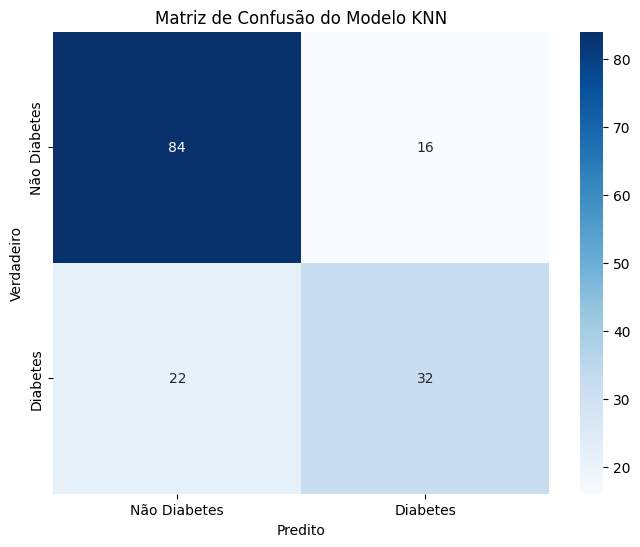

In [52]:
# Matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay
confusionMtz = confusion_matrix(y_true=y_test, y_pred=y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(confusionMtz, annot=True, fmt='d', cmap='Blues', xticklabels=["Não Diabetes", "Diabetes"], yticklabels=["Não Diabetes", "Diabetes"])
plt.title('Matriz de Confusão do Modelo KNN')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()


# SVM

In [53]:
# Treinar o modelo com SVM
from sklearn.svm import SVC

model_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_svm.fit(X_train_scaled, y_train)
y_pred_svm = model_svm.predict(X_test_scaled)
print("Acurácia do modelo SVM:", accuracy_score(y_test, y_pred_svm))

Acurácia do modelo SVM: 0.7337662337662337


In [54]:
print("Relatório de Classificação do modelo SVM:\n", classification_report(y_test, y_pred_svm))

Relatório de Classificação do modelo SVM:
               precision    recall  f1-score   support

           0       0.77      0.85      0.81       100
           1       0.65      0.52      0.58        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.73      0.73      0.73       154



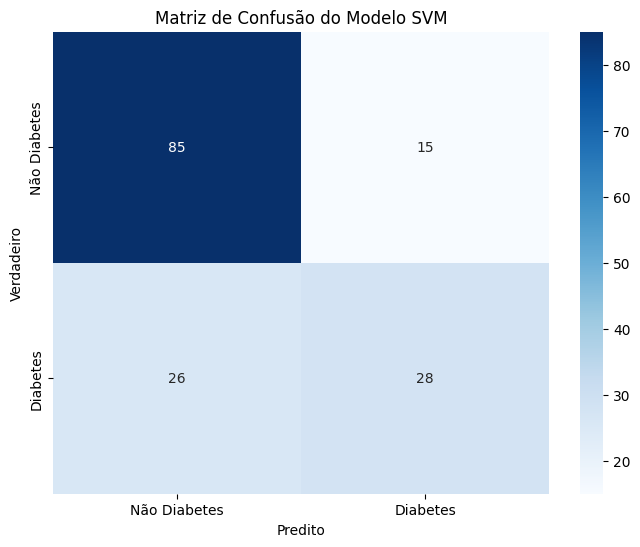

In [55]:
# Matriz de confusão do modelo SVM
confusion_svm = confusion_matrix(y_true=y_test, y_pred=y_pred_svm)
figure_svm = plt.figure(figsize=(8, 6))
disp_svm = sns.heatmap(confusion_svm, annot=True, fmt='d', cmap='Blues', xticklabels=["Não Diabetes", "Diabetes"], yticklabels=["Não Diabetes", "Diabetes"])
disp_svm.set_title('Matriz de Confusão do Modelo SVM')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()


# Feature Importance de KNN

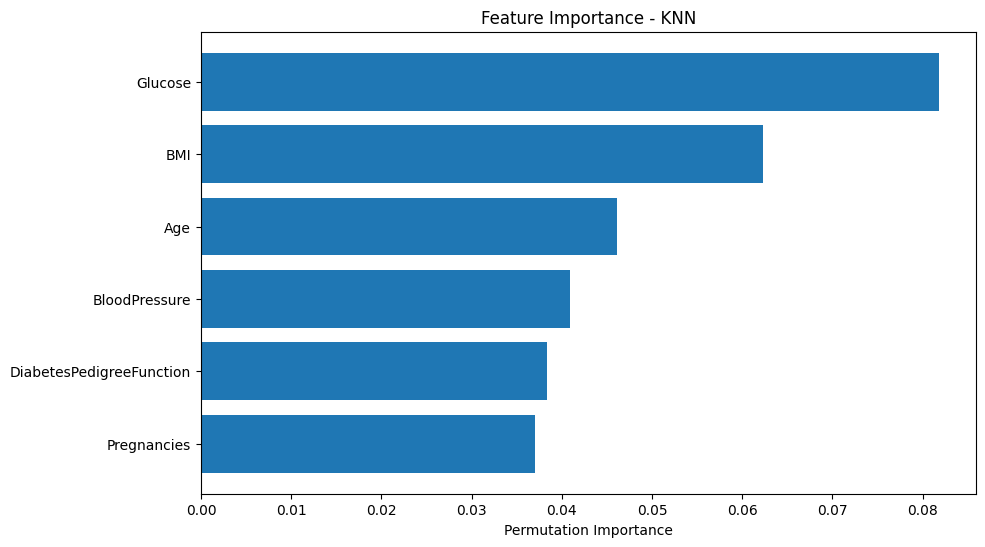

In [56]:
# Permutation Importance para KNN
from sklearn.inspection import permutation_importance
result_knn = permutation_importance(model_knn, X_test_scaled, y_test, n_repeats=10, random_state=42)
perm_importance_knn = pd.DataFrame({'Feature': X_train.columns, 'Importance': result_knn.importances_mean})
perm_importance_knn = perm_importance_knn.sort_values(by='Importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(perm_importance_knn['Feature'], perm_importance_knn['Importance'])
plt.xlabel('Permutation Importance')
plt.title('Feature Importance - KNN')
plt.show()

# Conclusões
- O modelo de KNN se saiu melhor que o modelo SVM
    - Acurácia de 75% para 73%
- Porém (vamos nos focar aqui no modelo KNN):
    - Para um modelo de previsões médicas, o problema são os falsos nagativos.
    - Na base de teste, de um total de 54 pacientes com diabetes, o modelo KNN previu erroneamente em 22 casos como falso negativo. São 22 pacientes com diabetes positivo que o modelo disse que o paciente não tem diabetes (40% dos casos positivos), o que é um problema importante. 
    - A métrica importante aqui é então o Recall, onde o modelo consegue em somente 59% dos casos avaliar corretamente diagnóstico de diabetes.
    - F1-Score em 63% é considerado razoável 
- Possíveis causas:
    - Apesar de termos removido as colunas "Insulin" e "SkinThickness", elas tinham muitas informações faltantes, o que pode demonstrar que tem muitas falhas no levantamento do dataset.
    - O modelo está desbalanceado: De um total de 768 casos, 500 são resultado negativo. 
        - Isso fica claro ao avaliar a precisão do modelo em diagnosticar "Não diabéticos": 77%, e na matriz de confusão que nos mostra um volume maior de acertos no diagnóstico de "Não diabéticos".    
- Avaliação de importancia das variáveis:
    - Glicose (Glucose) se mostrou a mais importenta
    - IMC (BMI) vem em seguida
    - Idade (Age) em 3ª posição
- Conclusão:
    - Para uso efetivo em produção para diagnósticos médicos, não é indicado, são necessárias melhorias
    - O F1-Score para uma aplicação médica deveria pelo menos na classe de "Muito bom" ou "Excelente", mais na verdade ficamos no "razoável" para nosso melhor modelo.
    - Talvez um dataset mais robusto seria melhor
        - Com mais casos
        - O dataset traz somente dados do gênero feminino e somente de uma etnia específica (Pima Indians)
        - Incluir indivíduos do gênero masculino pode trazer uma variadade interessante
        - Distribuição em outras etnias